# GPU sim best-practice A/B: physics dt + component placement — 2026-07-01

Follow-up to `gpusim_bench.ipynb`. Data produced by `notebooks/ab_dt_fidelity.py` (open-loop, 256 envs, identical per-env actions across cases) and the `smoke_gpusim_*` closed-loop RL smokes.

## Decisions
1. **Keep dt=0.002 (25 substeps).** The run-to-run null (same config twice) already has Spearman 0.953 / top-10% overlap 0.56 on per-env returns; dt=0.0025 (0.929/0.52) is indistinguishable from that null, dt=0.004 (0.860/0.16) and dt=0.005 (0.874/0.40) fall clearly below it → real physics shift. End-to-end the sim is only ~20% of a global step after the graph/nconmax fixes, so dt=0.005 buys just ~15% wallclock — not worth a fidelity change. `env.*.gpu_timestep` stays available.
2. **Placement: collocated `actor,env,rollout` on as many GPUs as the experiment owns.** mjwarp throughput is sublinear in batch, so fewer/bigger env workers are fine, but a heterogeneous layout (env on a GPU subset) was NOT faster — the env workers just contend with rollout on the shared GPUs. 512 envs: 1 GPU 116 s/step, 2 GPUs 73 s, 4 GPUs 55 s, 4 GPUs with env on 2 (het) 63 s.
3. Bonus correctness fix: peak nefc ≈ 610/world > old `njmax=350`; mjwarp silently drops overflowing constraint rows → default raised to 800.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
OUT = Path('/root/RLinf/logs/ab_dt')
CASES = ['gpu_dt2', 'gpu_dt25', 'gpu_dt4', 'gpu_dt5']
LABEL = {'gpu_dt2': 'dt=2ms (25 sub)', 'gpu_dt25': 'dt=2.5ms (20 sub)',
         'gpu_dt4': 'dt=4ms (12 sub, misaligned)', 'gpu_dt5': 'dt=5ms (10 sub)'}
def load(name, tag):
    return np.load(OUT / f'{name}_{tag}.npz')


## 1. Open-loop tracking reward curves (noise=0.01, 256 envs)
Same demo-target actions + identical per-env noise across all cases. CPU dt=2ms (8 envs) is the production reference.

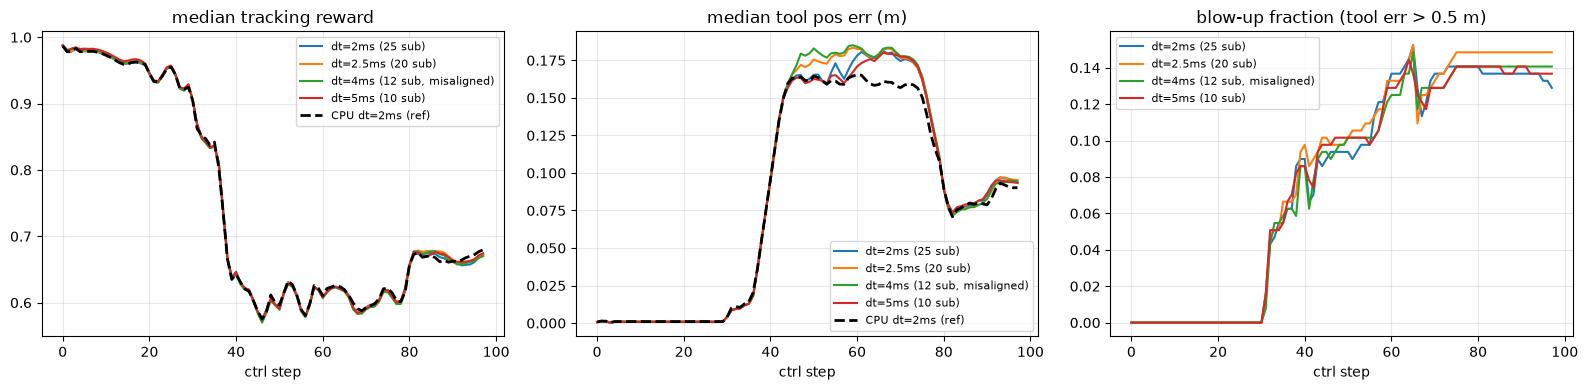

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cpu = load('cpu_dt2', 'noise0.01')
for name in CASES:
    z = load(name, 'noise0.01')
    r = z['rewards']
    axes[0].plot(np.nanmedian(r, 0), label=LABEL[name])
    axes[1].plot(np.nanmedian(z['tool_err'], 0), label=LABEL[name])
    blow = (z['tool_err'] > 0.5).mean(0)
    axes[2].plot(blow, label=LABEL[name])
axes[0].plot(np.nanmedian(cpu['rewards'], 0), 'k--', lw=2, label='CPU dt=2ms (ref)')
axes[1].plot(np.nanmedian(cpu['tool_err'], 0), 'k--', lw=2, label='CPU dt=2ms (ref)')
axes[0].set(title='median tracking reward', xlabel='ctrl step')
axes[1].set(title='median tool pos err (m)', xlabel='ctrl step')
axes[2].set(title='blow-up fraction (tool err > 0.5 m)', xlabel='ctrl step')
for a in axes: a.legend(fontsize=8); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. Return ranking consistency vs the run-to-run null
RAFT selects top-10% episodes by return, so what matters is whether dt changes the per-env return *ranking* more than mjwarp's inherent non-determinism (atomics → contact order) already does.

dt=2ms rerun (NULL)          spearman 0.953   top-10% overlap 0.56
dt=2.5ms (20 sub)            spearman 0.929   top-10% overlap 0.52
dt=4ms (12 sub, misaligned)  spearman 0.860   top-10% overlap 0.16
dt=5ms (10 sub)              spearman 0.874   top-10% overlap 0.40


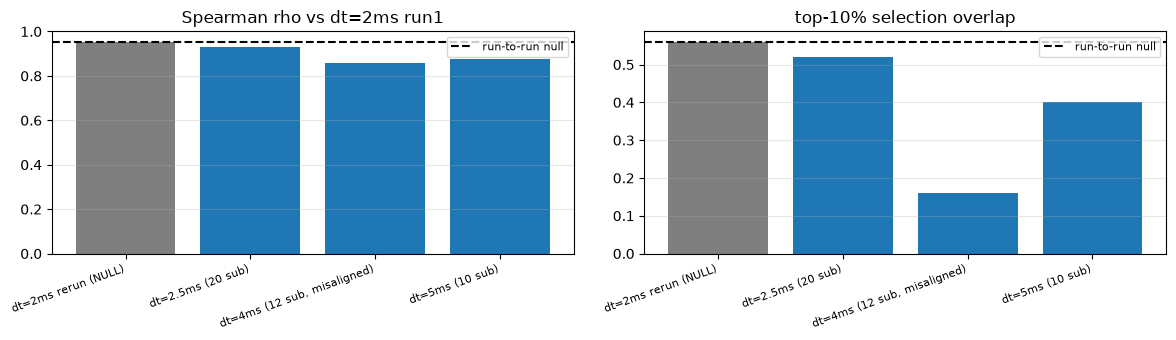

In [3]:
ref = load('gpu_dt2', 'noise0.01')
rows = [('dt=2ms rerun (NULL)', load('gpu_dt2', 'noise0.01_rep'))]
rows += [(LABEL[c], load(c, 'noise0.01')) for c in CASES[1:]]
k = int(0.1 * len(ref['returns']))
names, rhos, ovls = [], [], []
for name, z in rows:
    rho = stats.spearmanr(ref['returns'], z['returns']).statistic
    t1 = set(np.argsort(ref['returns'])[-k:]); t2 = set(np.argsort(z['returns'])[-k:])
    names.append(name); rhos.append(rho); ovls.append(len(t1 & t2) / k)
    print(f'{name:28s} spearman {rho:.3f}   top-10% overlap {len(t1 & t2) / k:.2f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, vals, ttl in [(axes[0], rhos, 'Spearman rho vs dt=2ms run1'),
                      (axes[1], ovls, 'top-10% selection overlap')]:
    bars = ax.bar(range(len(names)), vals, color=['tab:gray'] + ['tab:blue'] * 3)
    ax.axhline(vals[0], color='k', ls='--', label='run-to-run null')
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
    ax.set_title(ttl); ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## 3. Rollout visualization (open-loop, noise=0)
Panels left→right: **demo replay | CPU dt=2ms | GPU dt=2ms | GPU dt=2.5ms | GPU dt=5ms** (env 0). Full video: `logs/ab_dt/dt_ab_noise0.mp4`.

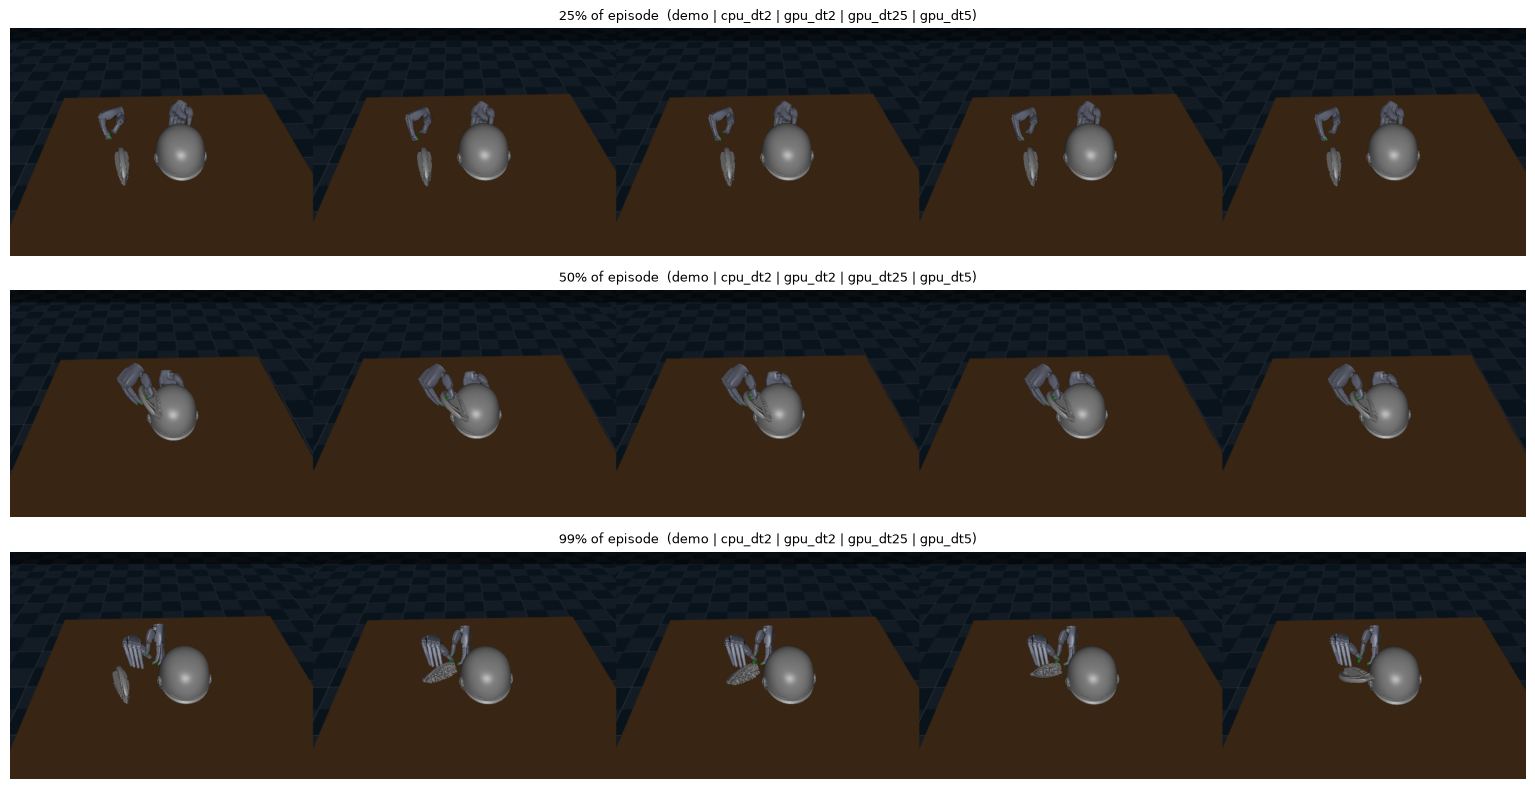

In [4]:
import imageio.v2 as imageio
fig, axes = plt.subplots(3, 1, figsize=(16, 8))
for ax, frac in zip(axes, (25, 50, 99)):
    ax.imshow(imageio.imread(OUT / f'dt_ab_noise0_f{frac:02d}.png'))
    ax.set_title(f'{frac}% of episode  (demo | cpu_dt2 | gpu_dt2 | gpu_dt25 | gpu_dt5)', fontsize=9)
    ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Closed-loop RL smokes (real policy, 256 envs, 3 global steps)
3-step smokes have large run-to-run variance (dt=2ms twice: success 0.32 vs 0.61), so these confirm *plumbing + magnitude* only; the open-loop ranking test above is the fidelity evidence.

| config | env_interact_step | global step | return | success | sim_nan |
|---|---|---|---|---|---|
| dt=2ms run1 | 15.0 s | 67 s | 58.3 | 0.32 | 0.8% |
| dt=2ms run2 (njmax=800) | 14.1 s | 73 s | 60.3 | 0.61 | 0.0% |
| dt=2.5ms | 12.8 s | 69 s | 57.5 | 0.26 | 1.6% |
| dt=5ms | 5.8 s | 59 s | 59.8 | 0.60 | 0.0% |


## 5. Placement matrix (512 envs, gbs 512, dt=2ms, 3 global steps)
All collocated unless noted. `het` = `actor,rollout: 0-3` + `env: 0-1`.

| GPUs | env workers | env_interact | generate_rollouts | actor train | global step |
|---|---|---|---|---|---|
| 1 | 1 x 512 envs | 20.6 s | 48.6 s | 65.8 s | **116.5 s** |
| 2 | 2 x 256 envs | 15.9 s | 34.2 s | 36.5 s | **73.4 s** |
| 4 | 4 x 128 envs | 14.9 s | 27.1 s | 24.0 s | **54.8 s** |
| 4 (het) | 2 x 256 envs | 14.8 s | 32.6 s | 26.3 s | **63.3 s** |

Takeaways: (a) sim time barely grows with fewer env workers (mjwarp sublinear batching) — env worker count is NOT the lever; (b) extra GPUs help mostly through actor training + rollout inference; (c) concentrating env workers on a GPU subset gives no win. **Best practice: keep the simple collocated `actor,env,rollout: <all GPUs of the experiment>`.**

Reference: same pipeline on CPU sim (live RAFT runs, 512 envs): env_interact ≈ 161 s, global step ≈ 260 s.